# Assessment Task 1
## Section 1(a): SVM Classifier with Raw Pixels
### 1. Extract files and Install all required dependencies and 

In [1]:
!unzip student_25349642.zip

Archive:  student_25349642.zip
replace student_25349642/+/+_100242.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [2]:
!pip install opencv-python-headless

In [3]:
!pip install split-folders

  Using cached split_folders-0.6.1-py3-none-any.whl.metadata (11 kB)
Using cached split_folders-0.6.1-py3-none-any.whl (13 kB)


In [4]:
import splitfolders

splitfolders.ratio("student_25349642", output="output", seed=1337, ratio=(.8, .1, .1),
                   group_prefix=None, group=None, formats=(".jpg", ".jpeg", ".png"), move=False, shuffle=True)

Copying files: 5000 files [00:04, 1229.09 files/s]


### 2. Dataset Preparation

**Finish writing in the section headings AFTER completing all the code**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature # This pacakge is used for LBP feature extraction
from sklearn import svm # This pacakge is used for svm classification
from sklearn import metrics
%matplotlib inline
import cv2
import seaborn as sns # This pacakge is used for better visualization of data (e.g confusion matrix)
import os
from sklearn.model_selection import train_test_split
from skimage.feature import local_binary_pattern
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from keras import layers
%load_ext tensorboard

2026-03-20 04:28:38.643403: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
labelName = ['+', 'beta', 'cos', 'leq', 'M', 'N', 'R', 'rightarrow', 'S', 'z']

def load_dataset(path):

    data = []
    labels = []

    for label in labelName:
        class_path = os.path.join(path, label)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (28, 28))

            img = img / 255.0
            data.append(img.flatten())
            labels.append(labelName.index(label))
            
    return np.array(data), np.array(labels)

In [7]:
X_train, y_train = load_dataset('./output/train')
X_test, y_test = load_dataset('./output/test')
X_val, y_val = load_dataset('./output/val')

In [8]:
print(np.shape(X_train))
print(np.shape(X_test))
print(np.shape(X_val))

(4000, 784)
(500, 784)
(500, 784)


In [29]:
model = svm.SVC(kernel='rbf', C = 100, random_state=42, gamma='scale')
model.fit(X_train, y_train)

,C,100
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [30]:
predictions = model.predict(X_test)

In [31]:
val_accuracy = model.score(X_val, y_val)
print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.924


In [32]:
# Check the training accuray
print("Train set Accuracy: {:.2f}".format(model.score(X_train,y_train)))

# Expected training set Accuracy 0.60

Train set Accuracy: 1.00


In [33]:
accuracy = metrics.accuracy_score(y_test, predictions)
print("Accuracy on test dataset:",accuracy)

Accuracy on test dataset: 0.93


[[48  0  0  0  1  1  0  0  0  0]
 [ 0 50  0  0  0  0  0  0  0  0]
 [ 0  0 46  0  4  0  0  0  0  0]
 [ 0  0  0 48  0  1  0  0  1  0]
 [ 0  0  0  0 44  6  0  0  0  0]
 [ 1  0  0  0  5 43  0  0  0  1]
 [ 0  2  0  0  0  4 44  0  0  0]
 [ 1  0  0  0  0  0  0 49  0  0]
 [ 0  0  0  1  0  2  1  0 46  0]
 [ 1  0  0  0  2  0  0  0  0 47]]


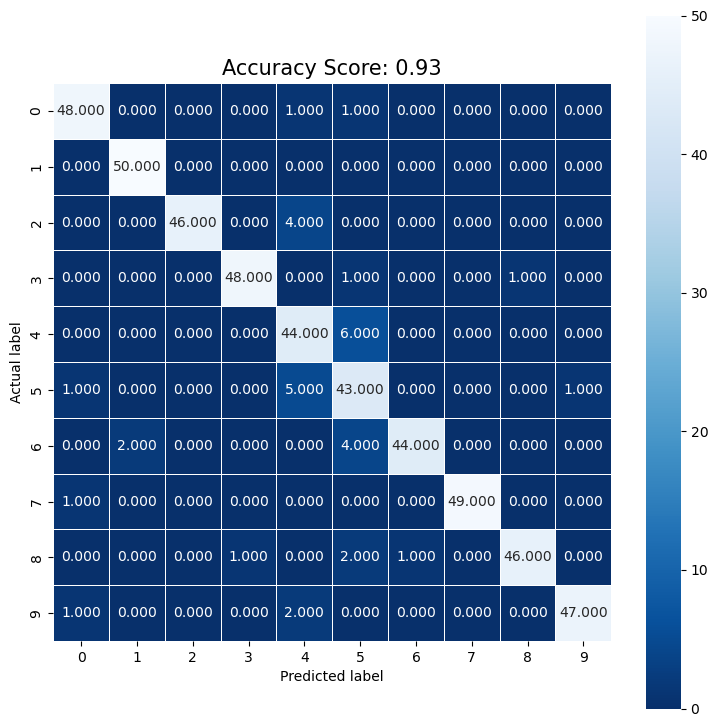

In [34]:
# plot the confusion matrix
cm  = metrics.confusion_matrix(y_test, predictions)
print(cm)

# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy)
plt.title(all_sample_title, size = 15);

In [36]:
# Display some classification result on test samples
images = []
pred_label = []
true_label = []

# randomly select a few testing fashion items
for i in np.random.choice(np.arange(0, len(y_test)), size=(16,)):
  # classify the clothing
  prediction = model.predict(X_test[i].reshape(1, -1))[0]
  label = labelName[prediction]
  orig_label = labelName[y_test[i]]
  image = X_test[i].reshape(28, 28)

  if image.max() <= 1.0:
      image = image * 255.0
  image = image.astype("uint8")
  image = cv2.merge([image] * 3)
  image = cv2.resize(image, (96, 96), interpolation=cv2.INTER_LINEAR)

  # cv2.putText(image, f"Predicted Label: {label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (0, 255, 0), 2)
  # cv2.putText(image, f"True Label: {orig_label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255, 0, 0), 2)
    
  images.append(image)
  pred_label.append(label)
  true_label.append(orig_label)

In [37]:
np.shape(images[1])

(96, 96, 3)

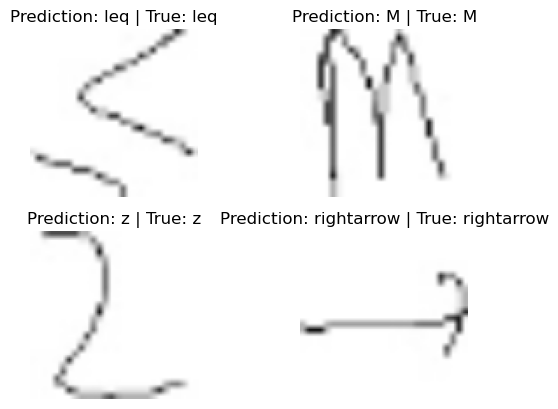

In [38]:
## Display the classification results
#Plot the image and the predicted labels
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(images[0])
ax1.set_title(f"Prediction: {pred_label[0]} | True: {true_label[0]}")
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(images[1])
ax2.set_title(f"Prediction: {pred_label[1]} | True: {true_label[1]}")
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(images[2])
ax3.set_title(f"Prediction: {pred_label[2]} | True: {true_label[2]}")
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(images[3])
ax4.set_title(f"Prediction: {pred_label[3]} | True: {true_label[3]}")
ax4.axis("off")
plt.show()

In [39]:
print("Test Accuracy: ", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions, target_names=labelName))

Test Accuracy:  0.93
              precision    recall  f1-score   support

           +       0.94      0.96      0.95        50
        beta       0.96      1.00      0.98        50
         cos       1.00      0.92      0.96        50
         leq       0.98      0.96      0.97        50
           M       0.79      0.88      0.83        50
           N       0.75      0.86      0.80        50
           R       0.98      0.88      0.93        50
  rightarrow       1.00      0.98      0.99        50
           S       0.98      0.92      0.95        50
           z       0.98      0.94      0.96        50

    accuracy                           0.93       500
   macro avg       0.94      0.93      0.93       500
weighted avg       0.94      0.93      0.93       500

